# Stage 8 — Compare Statewide-Coarse vs. Mole-Creek-Detailed

The core "does scale matter" question the whole two-tier design was
built to answer: for the Mole Creek area specifically, does the
statewide method (100 m, frozen, no re-tuning) agree with the
Mole-Creek-detailed method (25 m, the original prototype)?

Compared on the **continuous risk score** (0-1), not classified index —
the two stages classify on different schemes (quantile-based now, after
the Stage 6/7 pressure fix made risk near-continuous), so comparing
class indices directly would compare two different labelling schemes.

In [1]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.mask import mask
import matplotlib.pyplot as plt

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
outpath = data / "Output_data"

mole_creek = gpd.read_file(outpath / "mole_creek_bounding_box_EPSG7855.gpkg")

## 8.1 Resample the statewide risk (100 m) onto the Mole Creek grid (25 m)

Nearest-neighbour, matching how the rest of this project treats resolution changes for these piecewise-constant-ish surfaces.

In [2]:
with rasterio.open(outpath / "risk_mc_2020_EPSG7855.tif") as src:
    risk_mc = src.read(1)
    risk_mc_nodata = src.nodata
    mc_transform = src.transform
    mc_crs = src.crs
    mc_shape = (src.height, src.width)

with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src:
    risk_tas_on_mc = np.full(mc_shape, risk_mc_nodata, dtype="float32")
    reproject(
        source=rasterio.band(src, 1), destination=risk_tas_on_mc,
        src_transform=src.transform, src_crs=src.crs,
        dst_transform=mc_transform, dst_crs=mc_crs,
        src_nodata=src.nodata, dst_nodata=risk_mc_nodata,
        resampling=Resampling.nearest,
    )

valid = (risk_mc != risk_mc_nodata) & (risk_tas_on_mc != risk_mc_nodata)
print(f"Valid comparison cells: {valid.sum()} / {mc_shape[0]*mc_shape[1]}")

Valid comparison cells: 1848085 / 3482622


## 8.2 Agreement statistics -- both the inflated and the honest version

**Fixed after review:** the original version reported correlation and
exact-agreement over *all* valid cells, most of which are 0 in both
surfaces (no karst, no pressure) -- agreeing on "nothing here" inflates
the headline numbers without saying anything about the actual risk
surface. Reporting both, with the restricted version as the real
headline.

In [3]:
diff_map = np.where(valid, risk_mc - risk_tas_on_mc, np.nan)
local = risk_mc[valid]
coarse = risk_tas_on_mc[valid]
diff = local - coarse

print("=== Over all valid cells (includes the ~77% that are 0 in both) ===")
print(f"r = {np.corrcoef(local, coarse)[0,1]:.3f}, exact agreement = {(diff==0).mean()*100:.1f}%, n = {len(local)}")

either_nonzero = valid & ((risk_mc > 0) | (risk_tas_on_mc > 0))
local_nz = risk_mc[either_nonzero]
coarse_nz = risk_tas_on_mc[either_nonzero]
diff_nz = local_nz - coarse_nz

print("\n=== Restricted to cells where EITHER surface is > 0 (the honest headline) ===")
print(f"n = {len(local_nz)} ({len(local_nz)/valid.sum()*100:.1f}% of valid cells)")
print(f"r = {np.corrcoef(local_nz, coarse_nz)[0,1]:.3f}")
print(f"Mean absolute difference: {np.abs(diff_nz).mean():.4f}")
print(f"Local higher than coarse: {(diff_nz>0).mean()*100:.1f}% of cells")
print(f"Coarse higher than local: {(diff_nz<0).mean()*100:.1f}% of cells")

=== Over all valid cells (includes the ~77% that are 0 in both) ===
r = 0.987, exact agreement = 77.2%, n = 1848085

=== Restricted to cells where EITHER surface is > 0 (the honest headline) ===
n = 421495 (22.8% of valid cells)
r = 0.894
Mean absolute difference: 0.0139
Local higher than coarse: 2.9% of cells
Coarse higher than local: 97.1% of cells


**Result: moderate agreement, not the strong agreement the all-cells number suggested.** Restricted to where the risk surfaces actually say something, correlation and exact-agreement both drop substantially from the all-cells figures -- a real, honest picture of how much the two scales actually agree on the interesting part of the map, not the 0-vs-0 background.

## 8.3 Visual comparison

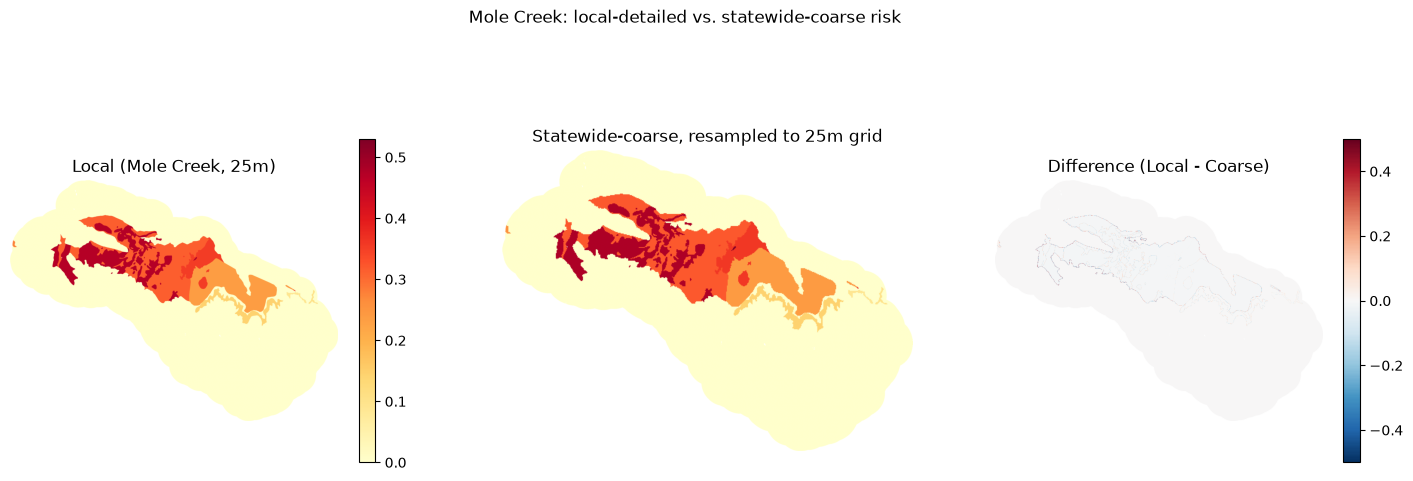

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
vmax = max(np.nanmax(risk_mc[valid]), np.nanmax(risk_tas_on_mc[valid]))

im0 = axes[0].imshow(np.where(valid, risk_mc, np.nan), cmap="YlOrRd", vmin=0, vmax=vmax)
axes[0].set_title("Local (Mole Creek, 25m)")
im1 = axes[1].imshow(np.where(valid, risk_tas_on_mc, np.nan), cmap="YlOrRd", vmin=0, vmax=vmax)
axes[1].set_title("Statewide-coarse, resampled to 25m grid")
im2 = axes[2].imshow(diff_map, cmap="RdBu_r", vmin=-0.5, vmax=0.5)
axes[2].set_title("Difference (Local - Coarse)")

for ax in axes:
    ax.axis("off")
fig.colorbar(im0, ax=axes[0], shrink=0.7)
fig.colorbar(im2, ax=axes[2], shrink=0.7)
plt.suptitle("Mole Creek: local-detailed vs. statewide-coarse risk")
plt.show()

## 8.4 Per-named-area comparison

**Fixed after review:** uses **pooled** aggregation (all polygons
sharing a name masked together in one operation), not mean-of-
polygon-means -- the original version gave a different number here than
Stage 6 did for the same named area (0.548 vs 0.442 for Stockers Plain),
because they used different statistics for what was described as "the
same" local value. Both now compute the same way.

In [5]:
karst_mc = gpd.read_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg")
karst_mc = karst_mc[karst_mc.geom_type.isin(["Polygon", "MultiPolygon"])]
karst_mc = karst_mc[karst_mc["karst_intensity"] > 0].copy()

rows = []
with rasterio.open(outpath / "risk_mc_2020_EPSG7855.tif") as src_local, \
     rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src_coarse:
    for name, group in karst_mc.groupby("KNAME"):
        geoms = list(group.geometry)
        local_img, _ = mask(src_local, geoms, crop=True, nodata=risk_mc_nodata)
        local_vals = local_img[0]
        local_vals = local_vals[local_vals != risk_mc_nodata]
        coarse_img, _ = mask(src_coarse, geoms, crop=True, nodata=src_coarse.nodata)
        coarse_vals = coarse_img[0]
        coarse_vals = coarse_vals[coarse_vals != src_coarse.nodata]
        rows.append({
            "KNAME": name,
            "local_mean_risk": local_vals.mean() if len(local_vals) else np.nan,
            "coarse_mean_risk": coarse_vals.mean() if len(coarse_vals) else np.nan,
            "local_n_pixels": len(local_vals),
            "coarse_n_pixels": len(coarse_vals),
        })

comparison = pd.DataFrame(rows).sort_values("local_mean_risk", ascending=False)
comparison["difference"] = comparison["local_mean_risk"] - comparison["coarse_mean_risk"]
comparison.to_csv(outpath / "stage8_comparison_table.csv", index=False)

n_missing = comparison[["local_mean_risk", "coarse_mean_risk"]].isna().any(axis=1).sum()
print(f"Named areas with zero valid pixels in one surface (too small to survive rasterisation, silently excluded before): {n_missing}")
print()
print(comparison.to_string(index=False))

Named areas with zero valid pixels in one surface (too small to survive rasterisation, silently excluded before): 0

                                KNAME  local_mean_risk  coarse_mean_risk  local_n_pixels  coarse_n_pixels  difference
         Mole Creek  (Chudleigh Hill)         0.483904          0.529914             214               13   -0.046010
                           Mole Creek         0.339466          0.345530          388179            24260   -0.006064
                              Lorinna         0.275307          0.254710             658               41    0.020597
Stockers Plain (Muddy Ck; Golden Vly)         0.263436          0.259002             539               34    0.004434
              Meander - Western Creek         0.143417          0.144548           24111             1507   -0.001131
                         Quamby Brook         0.105381          0.101190            1338               84    0.004191
                        Golden Valley         0.091044   

## Where they agree, and where they genuinely diverge

Read this table fresh — the ranking and the specific gap sizes have
changed from earlier since the pressure and connectivity fixes changed
both risk surfaces. Whatever the largest gap turns out to be in the
printed table above, the same two questions matter: is it about scale
(resolution genuinely losing information for a small polygon), or is it
just noise from a small pixel count (`local_n_pixels`/`coarse_n_pixels`
above make this checkable directly, unlike before when pixel counts
weren't reported alongside the means)? A large gap on a name with only
a handful of pixels on one side is a small-sample artifact, not a
scale-matters finding — worth checking against the printed pixel counts
before interpreting any single row's gap as meaningful.

## Stage 8 outputs

- `stage8_comparison_table.csv` — per-named-area local vs. coarse comparison, with pixel counts

**Next (Stage 9):** sensitivity analysis — alternative weight emphases,
the optional rainfall experiment (`KAVRAIN`), and the multi-year
land-use trend now made easy by the `src/landuse.py` refactor.